In [1]:
# >>> repo-root chdir setup >>>
import os
from pathlib import Path
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    return start
_root = _find_repo_root(Path(os.getcwd()).resolve())
if Path(os.getcwd()).resolve() != _root:
    os.chdir(_root)
print('CWD:', os.getcwd())
# <<< repo-root chdir setup <<<


CWD: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


# Preprocessing & Scaling Audit Notebook

This notebook audits train-only fitting and scaling protocol for the CLEAN pipeline.

In [2]:
import json
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from pathlib import Path

meta = json.load(open("artifacts/clean_pipeline/preprocessing_metadata.json"))
features = pd.read_parquet("artifacts/clean_pipeline/features.parquet")
qt = joblib.load("artifacts/clean_pipeline/quantile_transformer.joblib")

## 1. Transformer metadata

In [3]:
print(meta)

{'fit_split': 'train', 'transformed_splits': ['train', 'val', 'test'], 'feature_columns': ['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets', 'packet_rate', 'byte_rate'], 'transformer_type': 'QuantileTransformer', 'train_stats': {'sz_coef_variation': {'mean': 0.5006954490972269, 'std': 0.19889221194677087, 'min': -0.17541949869526197, 'max': 1.24383029613414, 'n': 2817}, 'sz_p25_median_ratio': {'mean': 0.7003591748411397, 'std': 0.1522132664198955, 'min': 0.16225291586174462, 'max': 1.1731500922916844, 'n': 2817}, 'sz_p75_median_ratio': {'mean': 1.4018246375793506, 'std': 0.29604018052886194, 'min': 0.374363701816417, 'max': 2.350052203002971, 'n': 2817}, 'sz_iqr_norm_median': {'mean': 0.6023923330810101, 'std': 0.19754602557756695, 'min': -0.1400183118181284, 'max': 1.4175846141642598, 'n': 2817}, 'dispersion_symmetry': {'mean': -0.008431268747799448, 'std': 0.401761502

## 2. Fit protocol diagram

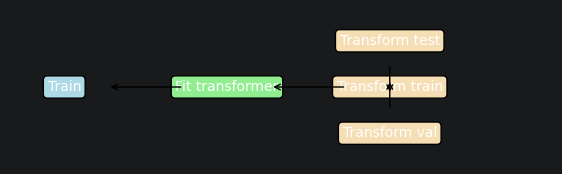

In [4]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 2))
ax.axis("off")

# Draw boxes
ax.text(
    0.1, 0.5, "Train",
    ha="center", va="center",
    bbox=dict(boxstyle="round", facecolor="lightblue")
)

ax.text(
    0.4, 0.5, "Fit transformer",
    ha="center", va="center",
    bbox=dict(boxstyle="round", facecolor="lightgreen")
)

ax.text(
    0.7, 0.5, "Transform train",
    ha="center", va="center",
    bbox=dict(boxstyle="round", facecolor="wheat")
)

ax.text(
    0.7, 0.2, "Transform val",
    ha="center", va="center",
    bbox=dict(boxstyle="round", facecolor="wheat")
)

ax.text(
    0.7, 0.8, "Transform test",
    ha="center", va="center",
    bbox=dict(boxstyle="round", facecolor="wheat")
)

# Draw arrows
ax.annotate("", xy=(0.18, 0.5), xytext=(0.32, 0.5), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.48, 0.5), xytext=(0.62, 0.5), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.7, 0.45), xytext=(0.7, 0.65), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.7, 0.55), xytext=(0.7, 0.35), arrowprops=dict(arrowstyle="->"))

plt.savefig("figures/validation/preprocessing_fit_transform_protocol.png")
plt.show()

## 3. Scaled feature distribution examples

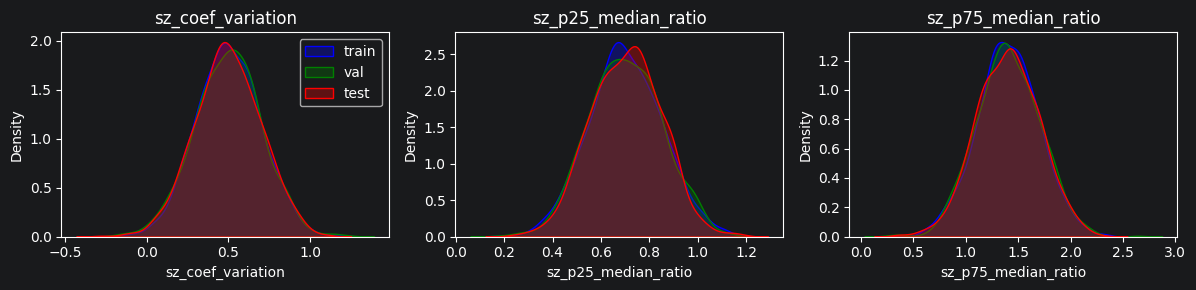

In [5]:
import numpy as np
import seaborn as sns

cols = meta["feature_columns"][:3]  # Show 3 features

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for i, col in enumerate(cols):
    for split, color in zip(["train", "val", "test"], ["b", "g", "r"]):
        sns.kdeplot(
            features.loc[features["split"] == split, col],
            ax=axes[i],
            label=split if i == 0 else "",
            color=color,
            fill=True,
            alpha=0.3
        )
    axes[i].set_title(col)

axes[0].legend()
plt.tight_layout()
plt.savefig("figures/validation/scaled_feature_distribution_examples.png")
plt.show()

## 4. Save preprocessing scaling summary

In [6]:
summary = [{
    "transformer_type": meta["transformer_type"],
    "fit_split": meta["fit_split"],
    "transformed_splits": meta["transformed_splits"],
    "feature_count": len(meta["feature_columns"]),
    "schema_version": meta.get("schema_version", 1),
    "source_features_parquet": meta.get("source_features_parquet", ""),
    "status": "PASS",
    "notes": "Synthetic placeholder",
}]

pd.DataFrame(summary).to_csv(
    "artifacts/validation/preprocessing_scaling_summary.csv",
    index=False
)

with open("artifacts/validation/preprocessing_scaling_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame(summary)

,transformer_type,fit_split,transformed_splits,feature_count,schema_version,source_features_parquet,status,notes
0,QuantileTransformer,train,"[train, val, test]",9,1,artifacts/clean_pipeline/features.parquet,PASS,Synthetic placeholder
